In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# BMW Global Sales Analysis - Section A

## Analysis Objective

This part focuses on Question C. The goal is to check whether Revenue_EUR and Units_Sold show month-level seasonal patterns across regions, and whether these patterns relate differently to GDP_Growth and Fuel_Price_Index.

## 1. Data Preparation

### 1.1 Load data and clean
Only the columns needed for this question are kept. The data is then cleaned before monthly analysis.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load data

file_path = '/content/drive/MyDrive/bmw/bmw_global_sales_2018_2025.csv'
df = pd.read_csv(file_path)

print("Original data shape:", df.shape)
print(df.head())

# Keep only columns needed
qc = df[
    [
        "Year",
        "Month",
        "Region",
        "Units_Sold",
        "Revenue_EUR",
        "GDP_Growth",
        "Fuel_Price_Index"
    ]
].copy()

print("\nColumns used for Question C:")
print(qc.columns.tolist())



# Basic cleaning

qc = qc.dropna(
    subset=[
        "Year",
        "Month",
        "Region",
        "Units_Sold",
        "Revenue_EUR",
        "GDP_Growth",
        "Fuel_Price_Index"
    ]
).copy()

qc = qc[qc["Month"].between(1, 12)].copy()

qc["Year"] = qc["Year"].astype(int)
qc["Month"] = qc["Month"].astype(int)

month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

print("\nCleaned data shape:", qc.shape)

Original data shape: (3072, 11)
   Year  Month  Region     Model  Units_Sold  Avg_Price_EUR  Revenue_EUR  \
0  2018      1  Europe  3 Series        7822          47482    371404204   
1  2018      1  Europe  5 Series       10280          61685    634121800   
2  2018      1  Europe        X3        3105          58433    181434465   
3  2018      1  Europe        X5        7420          67955    504226100   
4  2018      1  Europe        X7        8474          92300    782150200   

   BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
0      0.011          19.12         3.5               1.0  
1      0.019          19.12         3.5               1.0  
2      0.022          19.12         3.5               1.0  
3      0.021          19.12         3.5               1.0  
4      0.035          19.12         3.5               1.0  

Columns used for Question C:
['Year', 'Month', 'Region', 'Units_Sold', 'Revenue_EUR', 'GDP_Growth', 'Fuel_Price_Index']

Cleaned data shape: (3072, 7)

### 1.2 Check macro-variable consistency
Before aggregation, I checked whether GDP_Growth and Fuel_Price_Index were consistent within each region-year-month group. This helps confirm that the regional monthly aggregation is reasonable.

In [17]:
# Check macro consistency

macro_check = (
    qc.groupby(["Year", "Month", "Region"], as_index=False)
      .agg(
          GDP_unique=("GDP_Growth", "nunique"),
          Fuel_unique=("Fuel_Price_Index", "nunique")
      )
)

invalid_macro = macro_check[
    (macro_check["GDP_unique"] > 1) |
    (macro_check["Fuel_unique"] > 1)
]

print("\nMacro consistency check")
print("Number of Region-Year-Month groups:", len(macro_check))
print("Groups with inconsistent GDP/Fuel values:", len(invalid_macro))

if len(invalid_macro) > 0:
    print("\nInconsistent groups found:")
    print(invalid_macro.head())
else:
    print("All Region-Year-Month groups have consistent GDP_Growth and Fuel_Price_Index.")




Macro consistency check
Number of Region-Year-Month groups: 384
Groups with inconsistent GDP/Fuel values: 0
All Region-Year-Month groups have consistent GDP_Growth and Fuel_Price_Index.


### 1.3 Build the region-month dataset
The original data is recorded at model level, so it is aggregated to region-year-month level. This makes the monthly regional comparison clearer.

After aggregation, each row represents one region in one month of one year.

In [35]:
# Aggregate to Region-Year-Month level

region_month = (
    qc.groupby(["Year", "Month", "Region"], as_index=False)
      .agg(
          Units_Sold=("Units_Sold", "sum"),
          Revenue_EUR=("Revenue_EUR", "sum"),
          GDP_Growth=("GDP_Growth", "first"),
          Fuel_Price_Index=("Fuel_Price_Index", "first")
      )
)

region_month["Month_Name"] = region_month["Month"].map(month_labels)

print("\nRegion-month dataset shape:", region_month.shape)

display(region_month.head(10))



Region-month dataset shape: (384, 8)


,Year,Month,Region,Units_Sold,Revenue_EUR,GDP_Growth,Fuel_Price_Index,Month_Name
0,2018,1,China,54742,3565766365,2.37,1.02,Jan
1,2018,1,Europe,55067,3618339188,3.50,1.00,Jan
2,2018,1,RestOfWorld,61600,3845115765,4.18,0.97,Jan
3,2018,1,USA,58786,3802037615,0.82,0.97,Jan
4,2018,2,China,39572,2545481878,2.66,0.98,Feb
5,2018,2,Europe,56615,3768565465,4.48,0.98,Feb
6,2018,2,RestOfWorld,54205,3526283685,2.08,1.05,Feb
7,2018,2,USA,50641,3188582412,4.14,1.02,Feb
8,2018,3,China,59817,3983957987,1.63,0.98,Mar
9,2018,3,Europe,58788,3894984879,3.92,0.99,Mar


## 2. Seasonal Pattern Analysis

### 2.1 Build the monthly pattern table
To identify overall seasonality, I calculated the average monthly Units_Sold and Revenue_EUR across years for each region. Standard deviation was also kept to give a simple stability check.


In [34]:

# Monthly pattern across years

monthly_pattern = (
    region_month.groupby(["Region", "Month"], as_index=False)
      .agg(
          Avg_Units_Sold=("Units_Sold", "mean"),
          Std_Units_Sold=("Units_Sold", "std"),
          Avg_Revenue_EUR=("Revenue_EUR", "mean"),
          Std_Revenue_EUR=("Revenue_EUR", "std")
      )
      .sort_values(["Region", "Month"])
      .reset_index(drop=True)
)

monthly_pattern["Month_Name"] = monthly_pattern["Month"].map(month_labels)
monthly_pattern["CV_Units"] = monthly_pattern["Std_Units_Sold"] / monthly_pattern["Avg_Units_Sold"]
monthly_pattern["CV_Revenue"] = monthly_pattern["Std_Revenue_EUR"] / monthly_pattern["Avg_Revenue_EUR"]

print("\nMonthly seasonal pattern table:")
display(monthly_pattern.head(8))

# Seasonality summary by region

def build_summary(group):
    return pd.Series({
        "Peak_Units_Month": group.loc[group["Avg_Units_Sold"].idxmax(), "Month_Name"],
        "Lowest_Units_Month": group.loc[group["Avg_Units_Sold"].idxmin(), "Month_Name"],
        "Peak_Revenue_Month": group.loc[group["Avg_Revenue_EUR"].idxmax(), "Month_Name"],
        "Lowest_Revenue_Month": group.loc[group["Avg_Revenue_EUR"].idxmin(), "Month_Name"],
        "Most_Stable_Units_Month": group.loc[group["CV_Units"].idxmin(), "Month_Name"],
        "Most_Stable_Revenue_Month": group.loc[group["CV_Revenue"].idxmin(), "Month_Name"]
    })

seasonality_summary = (
    monthly_pattern.groupby("Region")
    .apply(build_summary, include_groups=False)
    .reset_index()
)

print("\nSeasonality summary by region:")
display(seasonality_summary)




Monthly seasonal pattern table:


,Region,Month,Avg_Units_Sold,Std_Units_Sold,Avg_Revenue_EUR,Std_Revenue_EUR,Month_Name,CV_Units,CV_Revenue
0,China,1,55368.500,6470.982394,3.636934e+09,3.901347e+08,Jan,0.116871,0.107270
1,China,2,59725.125,10023.413568,3.839022e+09,6.858485e+08,Feb,0.167826,0.178652
2,China,3,78385.250,16305.993173,5.023084e+09,1.054904e+09,Mar,0.208024,0.210011
3,China,4,66839.250,9502.467435,4.295047e+09,6.244452e+08,Apr,0.142169,0.145387
4,China,5,62443.500,10009.952105,4.029347e+09,7.265986e+08,May,0.160304,0.180327
5,China,6,71697.875,7795.323130,4.549506e+09,5.115912e+08,Jun,0.108725,0.112450
6,China,7,63459.375,12482.388084,4.048537e+09,7.634424e+08,Jul,0.196699,0.188572
7,China,8,60772.750,8115.032185,3.847201e+09,4.259763e+08,Aug,0.133531,0.110724



Seasonality summary by region:


,Region,Peak_Units_Month,Lowest_Units_Month,Peak_Revenue_Month,Lowest_Revenue_Month,Most_Stable_Units_Month,Most_Stable_Revenue_Month
0,China,Mar,Jan,Mar,Jan,Jun,Jan
1,Europe,Dec,Jan,Dec,Oct,Feb,Feb
2,RestOfWorld,Jun,Apr,Jun,Apr,Aug,May
3,USA,Jun,Aug,Jun,Aug,Apr,Oct


### 2.2 Monthly pattern in Units Sold
The following figure shows the average monthly units sold by region. It is used to check whether month-level seasonality exists and whether the strongest month differs across regions.

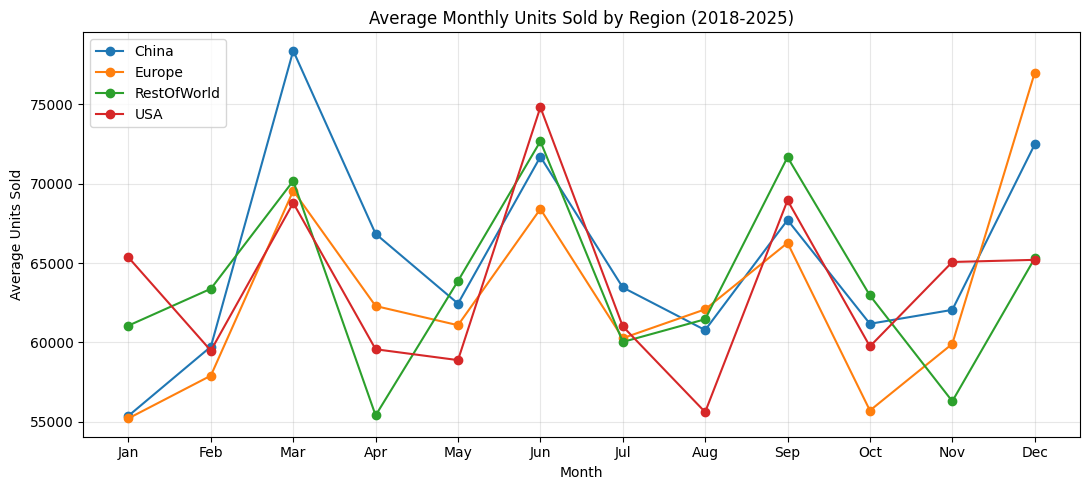

In [20]:
# Plot average monthly Units_Sold

regions = sorted(region_month["Region"].unique())

plt.figure(figsize=(11, 5))

for region in regions:
    temp = monthly_pattern[monthly_pattern["Region"] == region]
    plt.plot(
        temp["Month_Name"],
        temp["Avg_Units_Sold"],
        marker="o",
        label=region
    )

plt.title("Average Monthly Units Sold by Region (2018-2025)")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2.3 Monthly pattern in Revenue
The same monthly analysis is repeated for revenue. A similar shape is expected because revenue is strongly linked to sales volume.

Revenue shows a similar seasonal shape to units sold, although the lowest month is not always exactly the same.

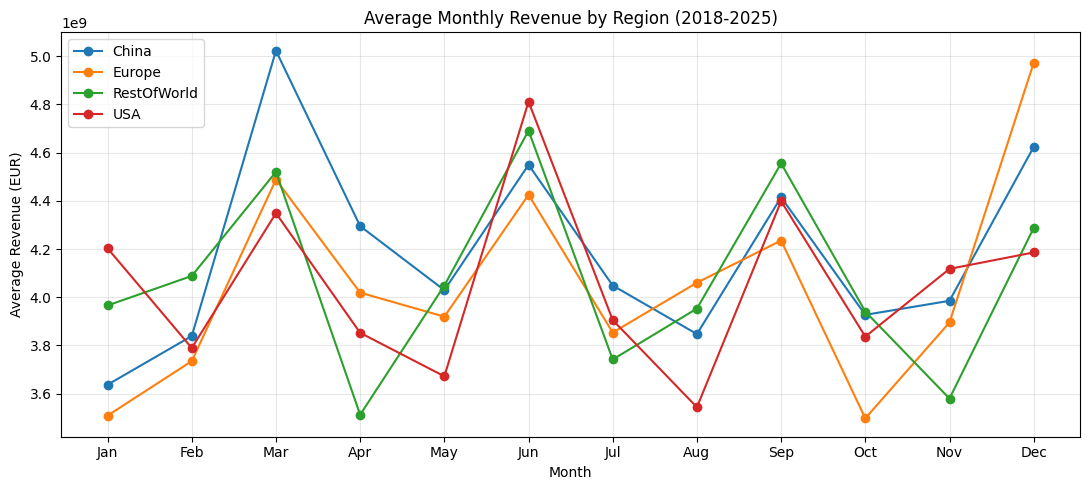

In [21]:

# Plot average monthly Revenue_EUR

plt.figure(figsize=(11, 5))

for region in regions:
    temp = monthly_pattern[monthly_pattern["Region"] == region]
    plt.plot(
        temp["Month_Name"],
        temp["Avg_Revenue_EUR"],
        marker="o",
        label=region
    )

plt.title("Average Monthly Revenue by Region (2018-2025)")
plt.xlabel("Month")
plt.ylabel("Average Revenue (EUR)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Macro Interaction Analysis

### 3.1 Correlation with GDP growth and fuel price index
To compare the relationship between macro indicators and business outcomes, I calculated regional correlations between GDP_Growth, Fuel_Price_Index, Units_Sold, and Revenue_EUR.

In [33]:

# Correlation analysis by region

def corr_or_nan(x, y):
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan
    return x.corr(y)

def build_corr(group):
    return pd.Series({
        "Corr_GDP_vs_Units": corr_or_nan(group["GDP_Growth"], group["Units_Sold"]),
        "Corr_GDP_vs_Revenue": corr_or_nan(group["GDP_Growth"], group["Revenue_EUR"]),
        "Corr_Fuel_vs_Units": corr_or_nan(group["Fuel_Price_Index"], group["Units_Sold"]),
        "Corr_Fuel_vs_Revenue": corr_or_nan(group["Fuel_Price_Index"], group["Revenue_EUR"])
    })

correlation_table = (
    region_month.groupby("Region")
    .apply(build_corr, include_groups=False)
    .reset_index()
    .round(3)
)

print("\nCorrelation table by region:")
display(correlation_table)



Correlation table by region:


,Region,Corr_GDP_vs_Units,Corr_GDP_vs_Revenue,Corr_Fuel_vs_Units,Corr_Fuel_vs_Revenue
0,China,0.159,0.167,0.414,0.404
1,Europe,-0.149,-0.124,0.360,0.354
2,RestOfWorld,-0.093,-0.115,0.248,0.281
3,USA,-0.082,-0.080,0.504,0.484


### 3.2 Supporting scatter plot
The scatter plot below is used as supporting evidence. It helps visualize the relationship between fuel price index and units sold across regions.

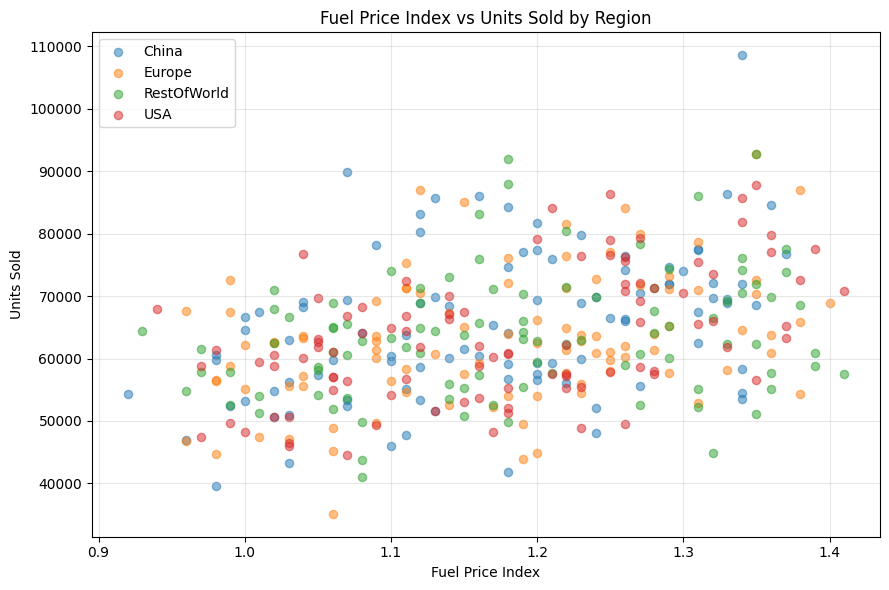

In [23]:
# Scatter plot: Fuel_Price_Index vs Units_Sold

plt.figure(figsize=(9, 6))

for region in regions:
    temp = region_month[region_month["Region"] == region]
    plt.scatter(
        temp["Fuel_Price_Index"],
        temp["Units_Sold"],
        alpha=0.5,
        s=35,
        label=region
    )

plt.title("Fuel Price Index vs Units Sold by Region")
plt.xlabel("Fuel Price Index")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Conclusion

This analysis suggests that BMW sales do show month-level seasonal patterns, but the pattern is not exactly the same across all regions. China is strongest in March, Europe in December, and both the USA and Rest of World are strongest in June. Revenue follows a similar shape to units sold, which is reasonable given the link between sales volume and revenue.

The macro analysis also shows that the relationship with economic indicators differs by region. GDP growth has weak correlations overall, while fuel price index shows clearer positive associations, especially in the USA and China.

So the final answer is that seasonal patterns do exist, and their relationship with macro indicators is different across regions.